# Attribute Inference Attacks on Machine Learning Models

## Research Question
Can we infer hidden/sensitive attributes from trained ML models by exploiting prediction confidence scores?

## Experimental Setup
- **4 Datasets**: 
  1. **Insurance** (Original POC) - Healthcare charges prediction
  2. **Personality** - Introvert/Extrovert classification
  3. **Occupation** - Adult Income census data
  4. **Stack Overflow** - Developer employment data
- **4 Model Types**: XGBoost, Decision Tree, Random Forest, Neural Network (MLP)
- **3 Fitting Scenarios**: Underfitted, Optimal, Overfitted
- **Attack Strategy**: For each hidden feature, test all possible values and select the one with highest prediction confidence

## Key Hypotheses
1. Overfitted models leak more information than well-fitted models
2. Attacks succeed better on training data than test data
3. Different model architectures have different privacy vulnerabilities
4. Different datasets have varying vulnerability levels based on feature correlations

## What's Included

**4 Datasets**: Insurance, Personality, Occupation (Adult Income), Stack Overflow  
**4 Model Types**: XGBoost, Decision Tree, Random Forest, Neural Network

**Total Experiments Possible**: 4 datasets × 4 models × 3 variants × 2 data types = 96 attack scenarios

## 1. Imports and Setup

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42

## 2. Core Attack Function

This implements the attribute inference attack from the Fredrikson et al. paper:
"The algorithm simply completes the target feature vector with each of the possible values for x1, 
and then computes a weighted probability estimate that this is the correct value."

In [4]:
def perform_attribute_inference(model, X_data, feature_col, possible_values):
    """
    Performs attribute inference attack on a single feature.
    
    Algorithm:
    For each record:
        1. Hide the target feature
        2. Create hypothetical records with ALL possible values for that feature
        3. Query the model for prediction confidence on each hypothetical
        4. Select the value that gives highest confidence
        5. Compare inferred value to true value
    
    Args:
        model: Trained sklearn pipeline
        X_data: DataFrame with features
        feature_col: Name of feature to infer
        possible_values: Array of all possible values for this feature
    
    Returns:
        DataFrame with real and inferred values
    """
    mappings = []
    
    for idx, row in X_data.iterrows():
        victim_row = row.copy()
        true_value = victim_row[feature_col]
        
        # Generate hypothetical records (one per possible value)
        attack_rows = []
        for val in possible_values:
            hypothetical_row = victim_row.copy()
            hypothetical_row[feature_col] = val
            hypothetical_row['guess_value'] = val
            attack_rows.append(hypothetical_row)
        
        attack_df = pd.DataFrame(attack_rows)
        X_attack = attack_df.drop('guess_value', axis=1)
        
        # Get prediction probabilities
        probs = model.predict_proba(X_attack)
        confidences = np.max(probs, axis=1)  # Max probability = confidence
        
        # Select guess with highest confidence
        best_guess_idx = np.argmax(confidences)
        inferred_val = attack_df.iloc[best_guess_idx]['guess_value']
        
        mappings.append({
            'true_value': true_value,
            'inferred_value': inferred_val,
            'correct': true_value == inferred_val
        })
    
    return pd.DataFrame(mappings)


def evaluate_attack(results_df, feature_name, baseline_random, baseline_majority):
    """
    Evaluates attack success rate against baselines.
    """
    attack_accuracy = results_df['correct'].mean()
    
    print(f"\n{'='*60}")
    print(f"Attack Results for: {feature_name}")
    print(f"{'='*60}")
    print(f"Attack Accuracy:        {attack_accuracy:.2%}")
    print(f"Random Baseline:        {baseline_random:.2%}")
    print(f"Majority Class Baseline: {baseline_majority:.2%}")
    print(f"\nAttack beats random?    {'YES ✓' if attack_accuracy > baseline_random else 'NO ✗'}")
    print(f"Attack beats majority?  {'YES ✓' if attack_accuracy > baseline_majority else 'NO ✗'}")
    
    if attack_accuracy > baseline_majority:
        print(f"\nPRIVACY LEAK DETECTED - Attack is {attack_accuracy/baseline_majority:.2f}x better than guessing!")
    
    return attack_accuracy

## 3. Dataset-Specific Configurations

Each dataset has different characteristics and requires specific handling.

In [ ]:
def get_dataset_config(dataset_name):
    """
    Returns configuration for each dataset.
    """
    configs = {
        'insurance': {
            'path': 'datasets/insurance.csv',
            'target': 'LABEL_CAT',
            'categorical_features': [
                'SEX',
                'SMOKER',
                'REGION',
                'BMI_CATEGORY',
                'HAS_CHILDREN'
            ],
            'numerical_features': [
                'AGE'
            ],
            'description': 'Healthcare Insurance - Charges Prediction (Original POC Dataset)',
            'needs_preprocessing': True  # This dataset needs feature engineering
        },
        'personality': {
            'path': 'datasets/personality_cleaned.csv',
            'target': 'Personality',
            'categorical_features': [
                'Stage_fear',
                'Drained_after_socializing',
                'Time_Alone_Category',
                'Social_Events_Category'
            ],
            'numerical_features': [
                'Going_outside',
                'Friends_circle_size',
                'Post_frequency'
            ],
            'description': 'Personality Classification (Intro/Extrovert)'
        },
        'occupation': {
            'path': 'datasets/occupation_cleaned_shrinked.csv',
            'target': 'Income',
            'categorical_features': [
                'Gender',
                'Race',
                # 'MaritalStatus',
                # 'Education',
                # 'Occupation'
            ],
            'numerical_features': [
                'Age',
                'EducationYears',
                'CapitalGain',
                'CapitalLoss',
                'HoursPerWeek'
            ],
            'description': 'Income Prediction (<=50K / >50K) - Adult Census Data'
        },
        'stackoverflow': {
            'path': 'datasets/stackoverflow_cleaned_shrinked.csv',
            'target': 'Employed',
            'categorical_features': [
                'EdLevel',      # Most balanced - PRIORITY
                'Age',          # Reasonably balanced
                'MentalHealth'  # Sensitive but imbalanced
                # Skip: Gender (93% Male), Accessibility (97% No), MainBranch (92% Dev)
            ],
            'numerical_features': [
                'Employment',
                'YearsCode',
                'YearsCodePro',
                'ComputerSkills'
            ],
            'description': 'Employment Status (Developer Survey Data)'
        }
    }
    return configs[dataset_name]


def preprocess_insurance_dataset(df):
    """
    Preprocesses the insurance dataset (from original POC).
    Performs feature engineering to create categorical features.
    """
    # 1. BMI Categories
    if "bmi" in df.columns:
        bins = [-np.inf, 18.5, 24.9, 29.9, np.inf]
        labels = ["0_UNDERWEIGHT", "1_HEALTHY", "2_OVERWEIGHT", "3_OBESITY"]
        df["BMI_CATEGORY"] = pd.cut(df["bmi"], bins=bins, labels=labels)
        df = df.drop("bmi", axis=1)
    
    # 2. Binary Flags
    if "children" in df.columns:
        df["HAS_CHILDREN"] = df["children"] >= 1
        df = df.drop("children", axis=1)
    
    # 3. Standardization: Rename columns to Uppercase
    rename_map = {
        "age": "AGE", "sex": "SEX", "smoker": "SMOKER", 
        "region": "REGION"
    }
    df = df.rename(columns=rename_map)
    
    # 4. Target Creation - Convert charges to quartiles
    if "charges" in df.columns:
        df['LABEL_CAT'] = pd.qcut(df['charges'], q=4, labels=['Q1', 'Q2', 'Q3', "Q4"])
        df = df.drop("charges", axis=1)
    
    return df


def load_dataset(dataset_name):
    """
    Loads and prepares a dataset for training.
    """
    config = get_dataset_config(dataset_name)
    
    print(f"\n{'='*70}")
    print(f"Loading Dataset: {dataset_name.upper()}")
    print(f"Description: {config['description']}")
    print(f"{'='*70}")
    
    # Load data
    df = pd.read_csv(config['path'])
    
    # Apply preprocessing if needed (for insurance dataset)
    if config.get('needs_preprocessing', False):
        print("Applying feature engineering (BMI categories, children flag, etc.)...")
        df = preprocess_insurance_dataset(df)
    
    print(f"Shape: {df.shape}")
    
    # Separate features and target
    X = df.drop(config['target'], axis=1)
    y_raw = df[config['target']]
    
    # Encode target if needed (handle both object and categorical dtypes)
    if y_raw.dtype == 'object' or pd.api.types.is_categorical_dtype(y_raw):
        label_encoder = LabelEncoder()
        y = label_encoder.fit_transform(y_raw)
        print(f"Target classes: {list(label_encoder.classes_)}")
    else:
        y = y_raw.values
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    
    print(f"Train: {X_train.shape[0]} samples")
    print(f"Test:  {X_test.shape[0]} samples")
    print(f"Categorical features ({len(config['categorical_features'])}): {config['categorical_features']}")
    print(f"Numerical features ({len(config['numerical_features'])}): {config['numerical_features']}")
    
    # Calculate baselines for each categorical feature
    baselines = {}
    for feat in config['categorical_features']:
        n_classes = df[feat].nunique()
        random_baseline = 1.0 / n_classes
        majority_baseline = df[feat].value_counts(normalize=True).max()
        baselines[feat] = {
            'random': random_baseline,
            'majority': majority_baseline,
            'n_classes': n_classes
        }
    
    return {
        'config': config,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'df_original': df,
        'baselines': baselines
    }

## 4. Model Definitions

We test 4 model architectures (as suggested in the topic description):
- **XGBoost**: Gradient boosted trees
- **Decision Tree**: Simple, prone to overfitting (mentioned in topic)
- **Random Forest**: Ensemble of trees
- **Neural Network (MLP)**: Multi-layer perceptron (mentioned in topic)

In [6]:
def create_preprocessing_pipeline(categorical_cols, numerical_cols):
    """
    Creates preprocessing pipeline for features.
    """
    return ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
            ('num', StandardScaler(), numerical_cols)
        ]
    )


def get_model_configs():
    """
    Defines model architectures with underfit/optimal/overfit variants.
    """
    return {
        'XGBoost': {
            'base_class': XGBClassifier,
            'base_params': {'random_state': RANDOM_STATE, 'eval_metric': 'logloss'},
            'grid_search_params': {
                'model__n_estimators': [50, 100, 200],
                'model__learning_rate': [0.01, 0.1, 0.3],
                'model__max_depth': [3, 6, 10]
            },
            'underfit_params': {
                'n_estimators': 10,
                'max_depth': 1,
                'learning_rate': 0.5
            },
            'overfit_params': {
                'n_estimators': 500,
                'max_depth': 15,
                'learning_rate': 0.3,
                'reg_lambda': 0,
                'min_child_weight': 1
            }
        },
        'DecisionTree': {
            'base_class': DecisionTreeClassifier,
            'base_params': {'random_state': RANDOM_STATE},
            'grid_search_params': {
                'model__max_depth': [5, 10, 15, 20],
                'model__min_samples_split': [2, 10, 20],
                'model__min_samples_leaf': [1, 5, 10]
            },
            'underfit_params': {
                'max_depth': 2,
                'min_samples_split': 100,
                'min_samples_leaf': 50
            },
            'overfit_params': {
                'max_depth': None,  # Unlimited depth
                'min_samples_split': 2,
                'min_samples_leaf': 1
            }
        },
        'RandomForest': {
            'base_class': RandomForestClassifier,
            'base_params': {'random_state': RANDOM_STATE, 'n_jobs': -1},
            'grid_search_params': {
                'model__n_estimators': [50, 100, 200],
                'model__max_depth': [10, 20, 30],
                'model__min_samples_split': [2, 5, 10]
            },
            'underfit_params': {
                'n_estimators': 10,
                'max_depth': 3,
                'min_samples_split': 50
            },
            'overfit_params': {
                'n_estimators': 500,
                'max_depth': None,
                'min_samples_split': 2,
                'min_samples_leaf': 1
            }
        },
        'NeuralNetwork': {
            'base_class': MLPClassifier,
            'base_params': {'random_state': RANDOM_STATE},
            'grid_search_params': {
                'model__hidden_layer_sizes': [(50,), (100,), (100, 50)],
                'model__alpha': [0.0001, 0.001, 0.01],
                'model__learning_rate_init': [0.001, 0.01],
                'model__max_iter': [500]
            },
            'underfit_params': {
                'hidden_layer_sizes': (10,),
                'alpha': 0.1,  # High regularization
                'max_iter': 50
            },
            'overfit_params': {
                'hidden_layer_sizes': (200, 100, 50),
                'alpha': 0.0001,  # Low regularization
                'max_iter': 1000
            }
        }
    }


def train_model_variants(model_name, X_train, y_train, preprocessor):
    """
    Trains 3 variants (underfit/optimal/overfit) of a single model type.
    
    This is the FIX for the redundant training issue in the original notebook!
    We train once, then reuse for all feature attacks.
    """
    print(f"\n{'='*70}")
    print(f"Training {model_name} variants...")
    print(f"{'='*70}")
    
    config = get_model_configs()[model_name]
    variants = {}
    
    # 1. UNDERFITTED Model
    print(f"\n1/3: Training UNDERFITTED {model_name}...")
    underfit_model = config['base_class'](**config['base_params'], **config['underfit_params'])
    underfit_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', underfit_model)
    ])
    underfit_pipeline.fit(X_train, y_train)
    variants['Underfitted'] = underfit_pipeline
    print(f"  ✓ Training complete")
    
    # 2. OPTIMAL Model (via GridSearch)
    print(f"\n2/3: Finding OPTIMAL {model_name} via GridSearch...")
    base_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', config['base_class'](**config['base_params']))
    ])
    
    grid_search = GridSearchCV(
        estimator=base_pipeline,
        param_grid=config['grid_search_params'],
        cv=3,
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train, y_train)
    variants['Optimal'] = grid_search.best_estimator_
    print(f"  ✓ Best params: {grid_search.best_params_}")
    print(f"  ✓ Best CV score: {grid_search.best_score_:.4f}")
    
    # 3. OVERFITTED Model
    print(f"\n3/3: Training OVERFITTED {model_name}...")
    overfit_model = config['base_class'](**config['base_params'], **config['overfit_params'])
    overfit_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', overfit_model)
    ])
    overfit_pipeline.fit(X_train, y_train)
    variants['Overfitted'] = overfit_pipeline
    print(f"  ✓ Training complete")
    
    # Evaluate all variants
    print(f"\n{model_name} Performance Summary:")
    print(f"{'Variant':<15} {'Train Acc':<12} {'Test Acc':<12}")
    print("-" * 40)
    
    return variants

## 5. Main Experiment Loop

**FIXED STRUCTURE** (vs original notebook):
1. For each dataset
2. For each model type
3. Train 3 variants (underfit/optimal/overfit) ONCE
4. Attack ALL categorical features with these trained models
5. Compare results

**Original notebook problem**: Trained models redundantly for each feature

In [7]:
def run_comprehensive_attack_experiment(dataset_name, model_types=['XGBoost', 'DecisionTree']):
    """
    Runs complete attribute inference experiment on one dataset.
    
    Args:
        dataset_name: 'personality', 'occupation', or 'stackoverflow'
        model_types: List of model types to test
    
    Returns:
        Dictionary with all attack results
    """
    # Load dataset
    data = load_dataset(dataset_name)
    config = data['config']
    
    # Create preprocessing pipeline
    preprocessor = create_preprocessing_pipeline(
        config['categorical_features'],
        config['numerical_features']
    )
    
    # Store all results
    all_results = []
    
    # === TRAIN MODELS (ONCE PER MODEL TYPE) ===
    trained_models = {}
    for model_name in model_types:
        variants = train_model_variants(
            model_name,
            data['X_train'],
            data['y_train'],
            preprocessor
        )
        trained_models[model_name] = variants
    
    print(f"\n\n{'#'*70}")
    print(f"# STARTING ATTRIBUTE INFERENCE ATTACKS")
    print(f"{'#'*70}\n")
    
    # === ATTACK ALL FEATURES WITH ALL TRAINED MODELS ===
    for feature in config['categorical_features']:
        print(f"\n{'='*70}")
        print(f"TARGET FEATURE: {feature}")
        print(f"{'='*70}")
        
        possible_values = data['df_original'][feature].unique()
        baselines = data['baselines'][feature]
        
        print(f"Possible values ({baselines['n_classes']}): {list(possible_values)}")
        print(f"Random baseline: {baselines['random']:.2%}")
        print(f"Majority baseline: {baselines['majority']:.2%}")
        
        # Attack with each model type and variant
        for model_name in model_types:
            for variant_name, model in trained_models[model_name].items():
                
                # Attack train data (members)
                print(f"\n  [{model_name} - {variant_name}] Attacking TRAIN data...")
                train_results = perform_attribute_inference(
                    model,
                    data['X_train'],
                    feature,
                    possible_values
                )
                train_acc = train_results['correct'].mean()
                
                # Attack test data (non-members)
                print(f"  [{model_name} - {variant_name}] Attacking TEST data...")
                test_results = perform_attribute_inference(
                    model,
                    data['X_test'],
                    feature,
                    possible_values
                )
                test_acc = test_results['correct'].mean()
                
                # Store results
                all_results.append({
                    'Dataset': dataset_name,
                    'Feature': feature,
                    'Model': model_name,
                    'Variant': variant_name,
                    'Data': 'Train',
                    'Attack_Accuracy': train_acc,
                    'Random_Baseline': baselines['random'],
                    'Majority_Baseline': baselines['majority']
                })
                all_results.append({
                    'Dataset': dataset_name,
                    'Feature': feature,
                    'Model': model_name,
                    'Variant': variant_name,
                    'Data': 'Test',
                    'Attack_Accuracy': test_acc,
                    'Random_Baseline': baselines['random'],
                    'Majority_Baseline': baselines['majority']
                })
                
                print(f"    Train Acc: {train_acc:.2%} | Test Acc: {test_acc:.2%}")
    
    return pd.DataFrame(all_results)

## 6. Visualization Functions

In [8]:
def plot_attack_comparison(results_df, dataset_name):
    """
    Creates comprehensive visualization of attack results.
    """
    features = results_df['Feature'].unique()
    
    for feature in features:
        feature_data = results_df[results_df['Feature'] == feature]
        
        # Get baselines
        random_baseline = feature_data['Random_Baseline'].iloc[0]
        majority_baseline = feature_data['Majority_Baseline'].iloc[0]
        
        # Create plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Plot 1: All models comparison
        sns.barplot(
            data=feature_data,
            x='Variant',
            y='Attack_Accuracy',
            hue='Data',
            ax=ax1,
            palette='viridis'
        )
        ax1.axhline(random_baseline, color='red', linestyle='--', 
                   label=f'Random ({random_baseline:.1%})', linewidth=2)
        ax1.axhline(majority_baseline, color='orange', linestyle=':', 
                   label=f'Majority ({majority_baseline:.1%})', linewidth=2)
        ax1.set_ylim(0, 1.05)
        ax1.set_title(f'{dataset_name.upper()} - {feature}\nAttack Success by Model Variant')
        ax1.set_ylabel('Attack Accuracy')
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3)
        
        # Plot 2: Model type comparison
        model_comparison = feature_data[feature_data['Variant'] == 'Overfitted']
        sns.barplot(
            data=model_comparison,
            x='Model',
            y='Attack_Accuracy',
            hue='Data',
            ax=ax2,
            palette='mako'
        )
        ax2.axhline(majority_baseline, color='orange', linestyle=':', 
                   label=f'Majority ({majority_baseline:.1%})', linewidth=2)
        ax2.set_ylim(0, 1.05)
        ax2.set_title(f'{dataset_name.upper()} - {feature}\nModel Architecture Comparison (Overfitted)')
        ax2.set_ylabel('Attack Accuracy')
        ax2.legend()
        ax2.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()


def create_summary_table(results_df):
    """
    Creates a summary table of key findings.
    """
    # Calculate success rate (attack > majority baseline)
    results_df['Successful_Attack'] = results_df['Attack_Accuracy'] > results_df['Majority_Baseline']
    results_df['Improvement_Over_Baseline'] = results_df['Attack_Accuracy'] / results_df['Majority_Baseline']
    
    summary = results_df.groupby(['Dataset', 'Feature', 'Model', 'Variant', 'Data']).agg({
        'Attack_Accuracy': 'mean',
        'Majority_Baseline': 'first',
        'Successful_Attack': 'first',
        'Improvement_Over_Baseline': 'first'
    }).reset_index()
    
    summary = summary.sort_values('Attack_Accuracy', ascending=False)
    
    print("\n" + "="*100)
    print("ATTACK SUMMARY - TOP 10 MOST SUCCESSFUL ATTACKS")
    print("="*100)
    print(summary.head(10).to_string(index=False))
    
    return summary

## 7. Run Experiments

Now we execute the complete experimental pipeline on all datasets.

### 7.1 Experiment 1: Insurance Dataset (Original POC)

In [9]:
# Run on Insurance dataset (Original POC dataset)
insurance_results = run_comprehensive_attack_experiment(
    'insurance',
    model_types=['XGBoost', 'DecisionTree', 'RandomForest', 'NeuralNetwork']
)


Loading Dataset: INSURANCE
Description: Healthcare Insurance - Charges Prediction (Original POC Dataset)
Applying feature engineering (BMI categories, children flag, etc.)...
Shape: (1338, 7)
Target classes: ['Q1', 'Q2', 'Q3', 'Q4']
Train: 1070 samples
Test:  268 samples
Categorical features (5): ['SEX', 'SMOKER', 'REGION', 'BMI_CATEGORY', 'HAS_CHILDREN']
Numerical features (1): ['AGE']

Training XGBoost variants...

1/3: Training UNDERFITTED XGBoost...
  ✓ Training complete

2/3: Finding OPTIMAL XGBoost via GridSearch...
  ✓ Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
  ✓ Best CV score: 0.8654

3/3: Training OVERFITTED XGBoost...
  ✓ Training complete

XGBoost Performance Summary:
Variant         Train Acc    Test Acc    
----------------------------------------

Training DecisionTree variants...

1/3: Training UNDERFITTED DecisionTree...
  ✓ Training complete

2/3: Finding OPTIMAL DecisionTree via GridSearch...
  ✓ Best params: {'mod

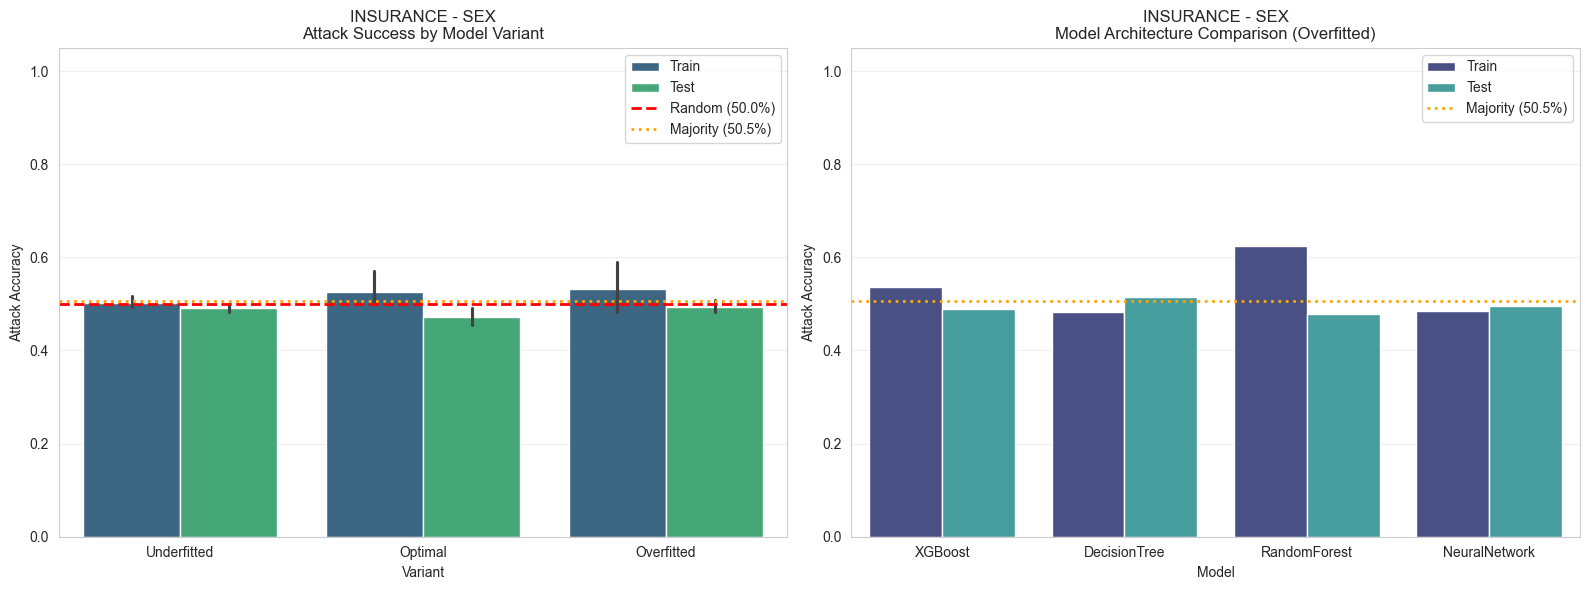

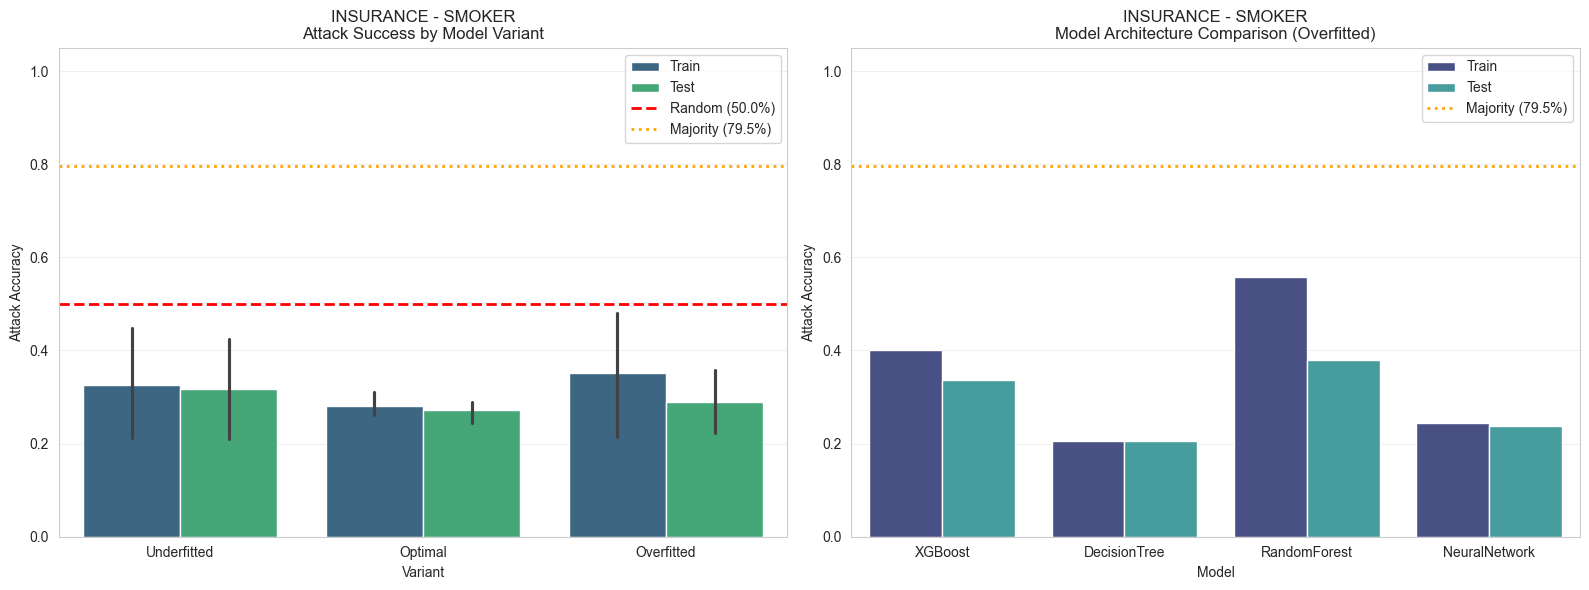

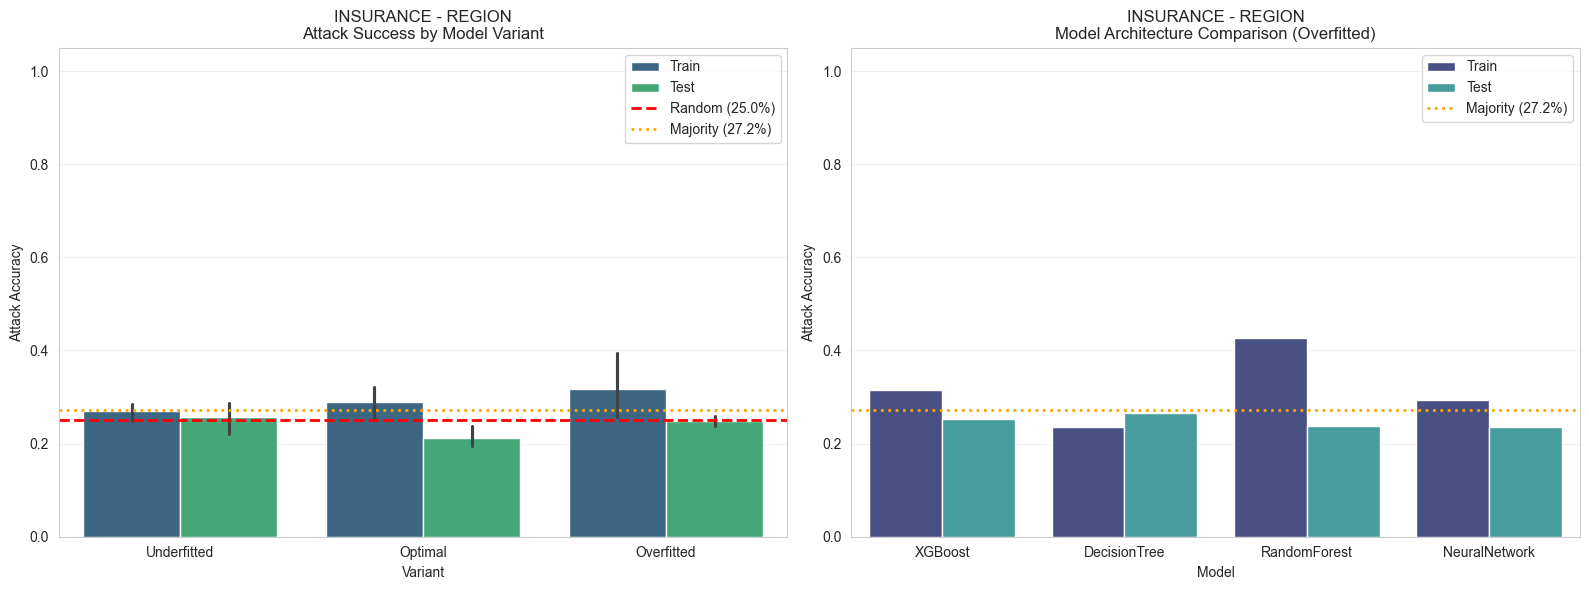

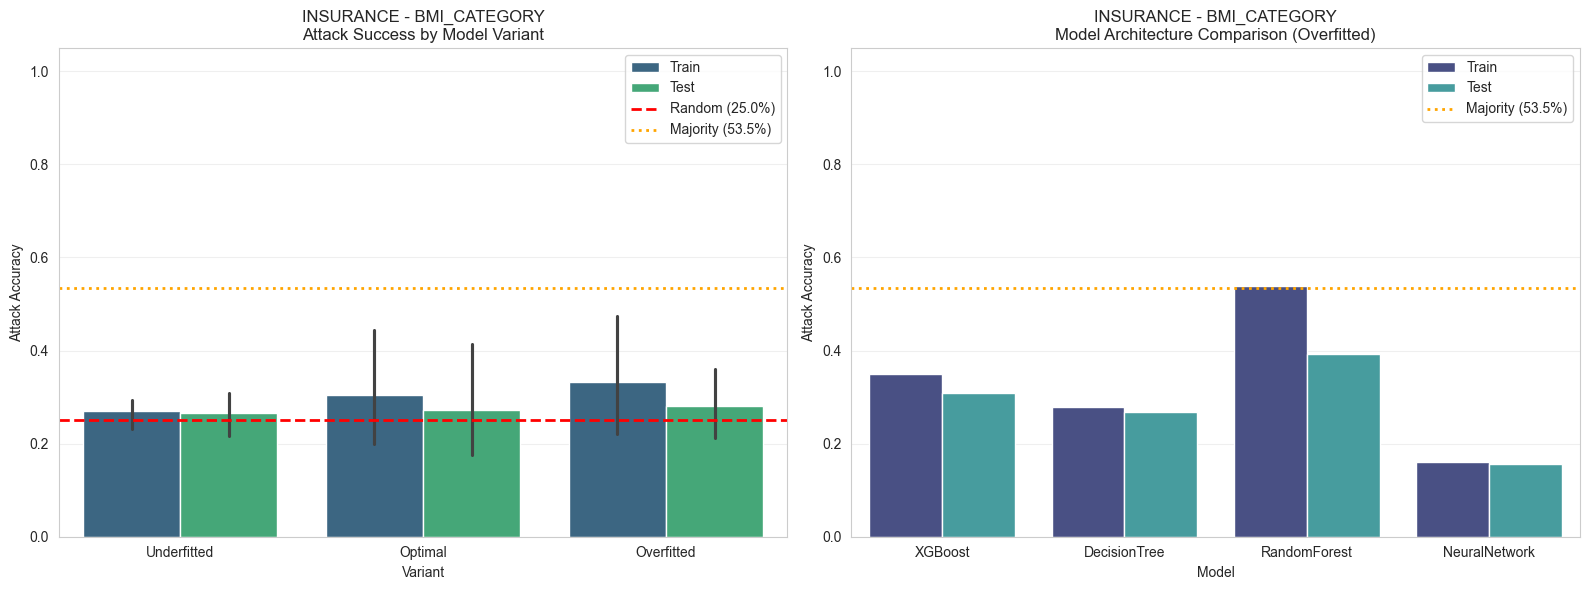

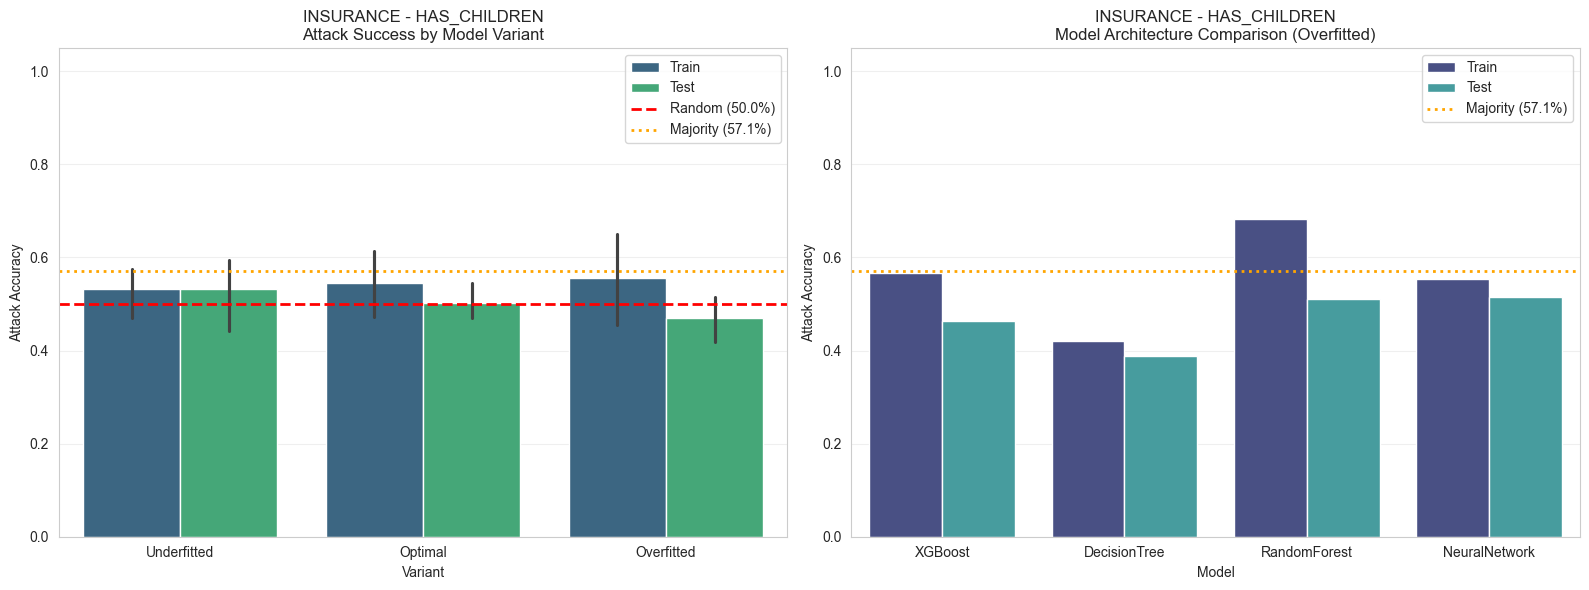

In [10]:
# Visualize results
plot_attack_comparison(insurance_results, 'insurance')

### 7.2 Experiment 2: Personality Dataset

In [11]:
# Run on Personality dataset with 2 model types first (for faster testing)
personality_results = run_comprehensive_attack_experiment(
    'personality',
    model_types=['XGBoost', 'DecisionTree', 'RandomForest', 'NeuralNetwork']
)


Loading Dataset: PERSONALITY
Description: Personality Classification (Intro/Extrovert)
Shape: (5000, 8)
Target classes: ['Extrovert', 'Introvert']
Train: 4000 samples
Test:  1000 samples
Categorical features (4): ['Stage_fear', 'Drained_after_socializing', 'Time_Alone_Category', 'Social_Events_Category']
Numerical features (3): ['Going_outside', 'Friends_circle_size', 'Post_frequency']

Training XGBoost variants...

1/3: Training UNDERFITTED XGBoost...
  ✓ Training complete

2/3: Finding OPTIMAL XGBoost via GridSearch...
  ✓ Best params: {'model__learning_rate': 0.3, 'model__max_depth': 3, 'model__n_estimators': 50}
  ✓ Best CV score: 0.9930

3/3: Training OVERFITTED XGBoost...
  ✓ Training complete

XGBoost Performance Summary:
Variant         Train Acc    Test Acc    
----------------------------------------

Training DecisionTree variants...

1/3: Training UNDERFITTED DecisionTree...
  ✓ Training complete

2/3: Finding OPTIMAL DecisionTree via GridSearch...
  ✓ Best params: {'model

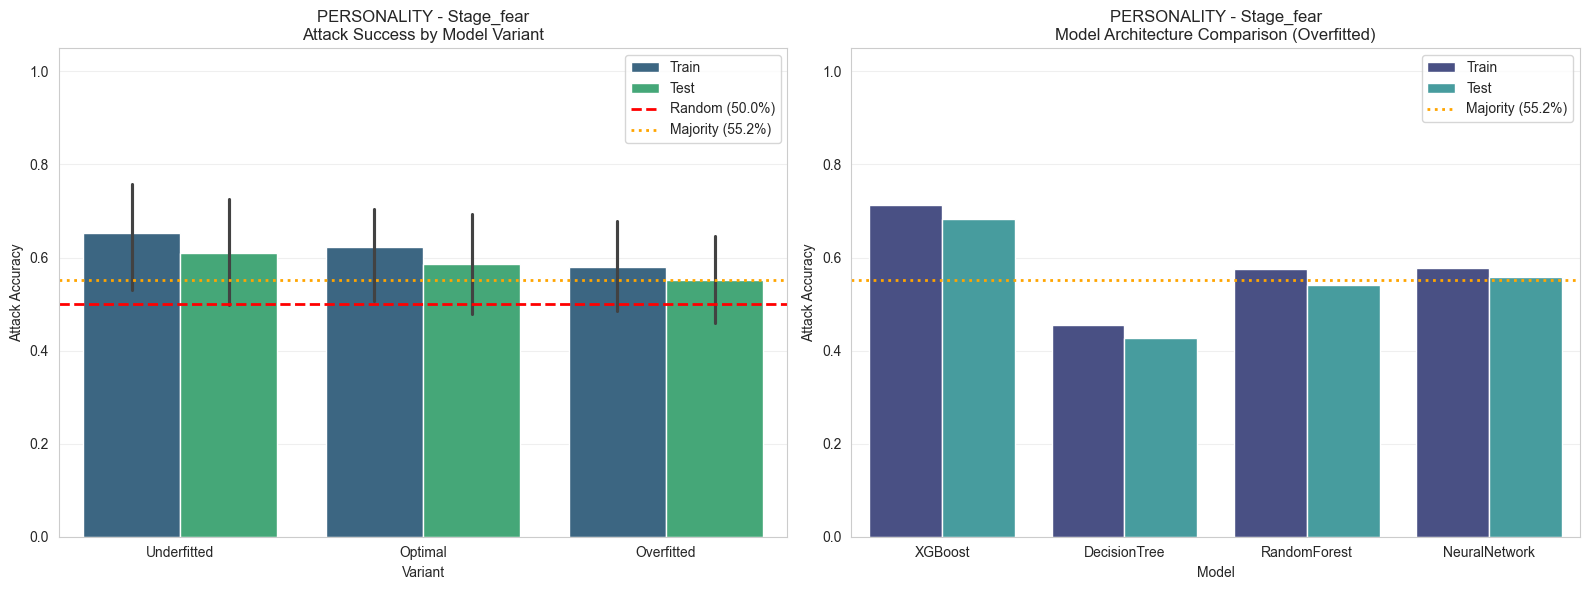

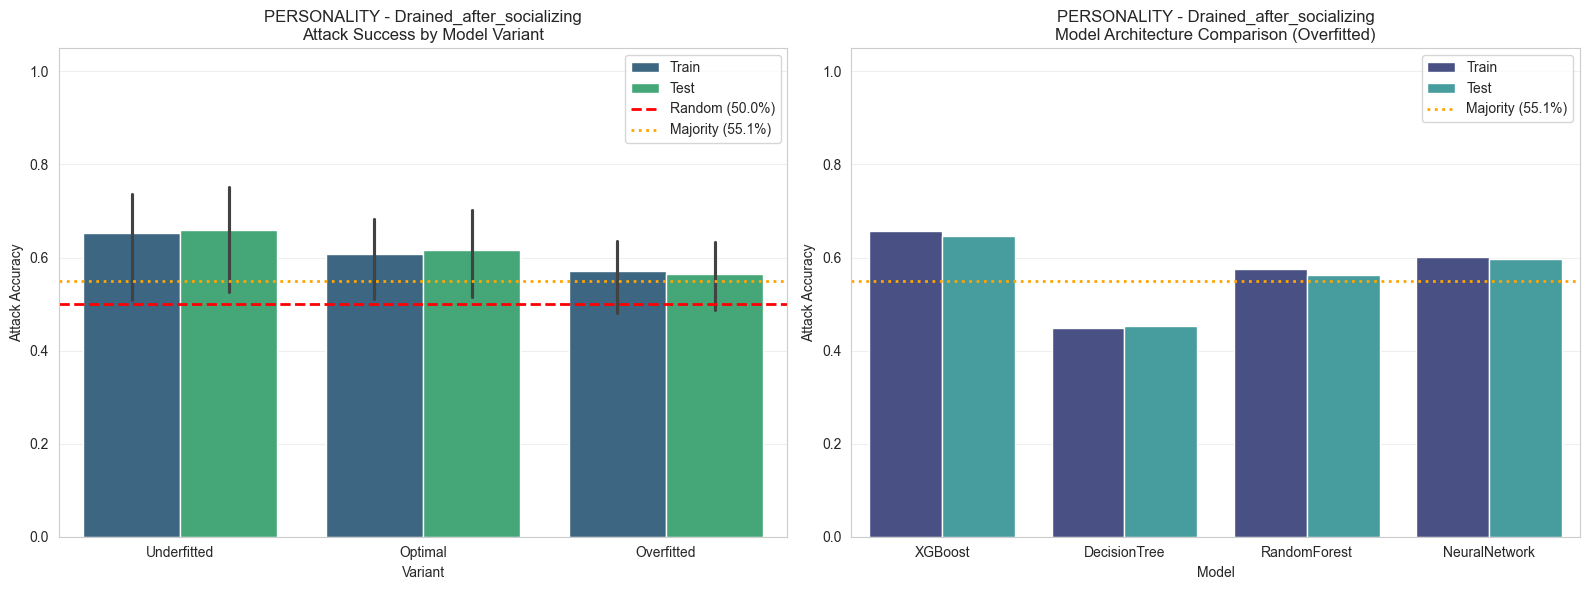

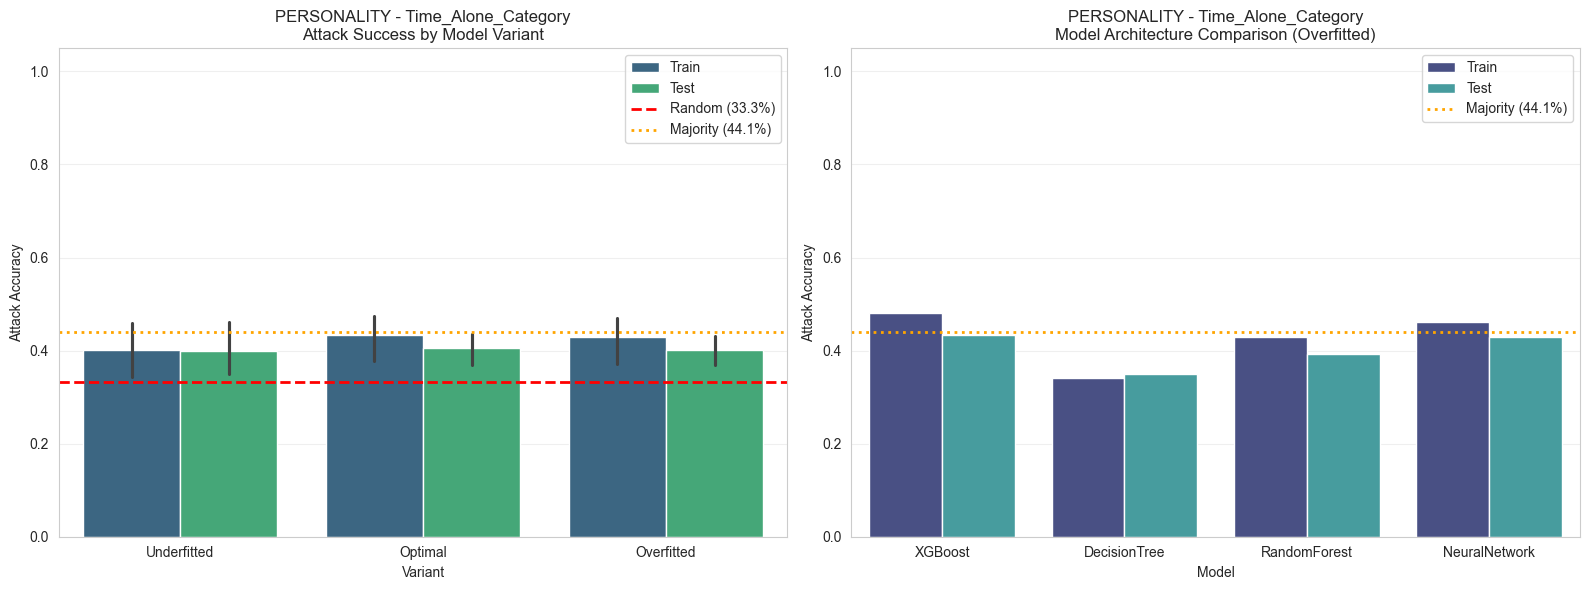

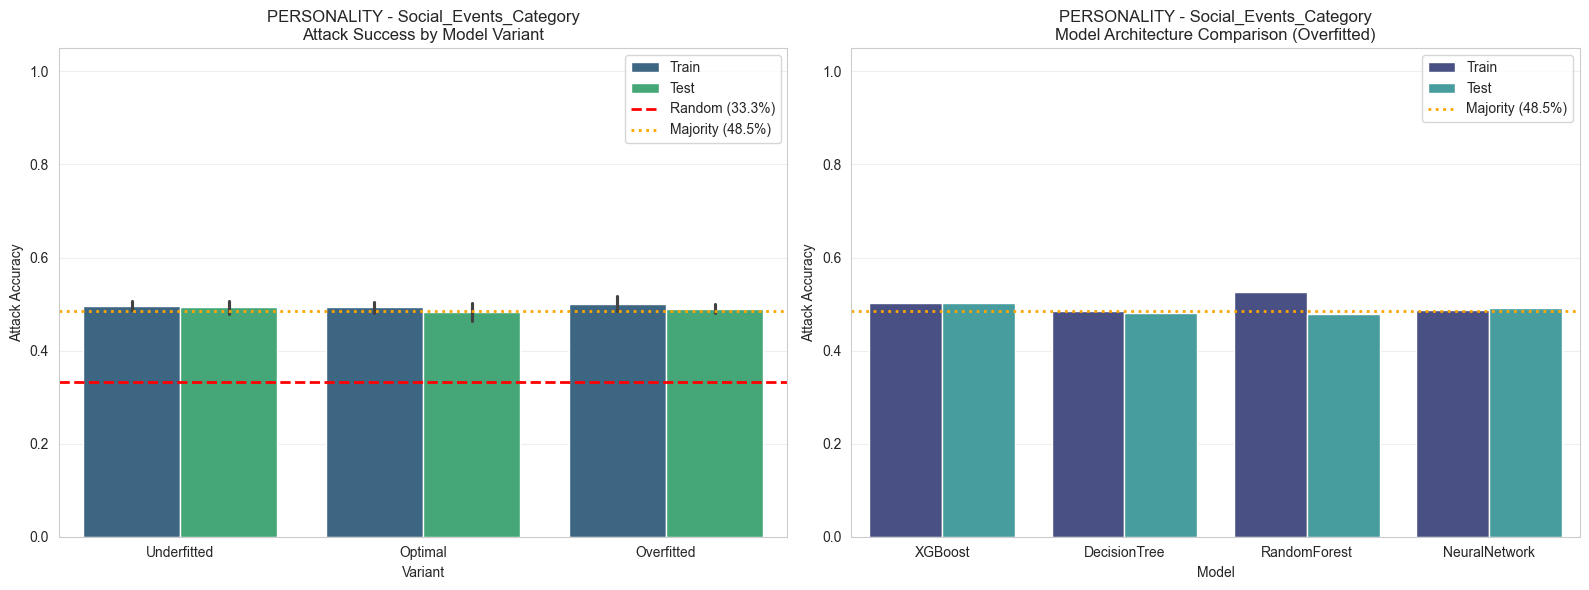

In [12]:
# Visualize results
plot_attack_comparison(personality_results, 'personality')

### 7.3 Experiment 3: Occupation Dataset (Adult Income)

In [9]:
# Run on Occupation dataset
occupation_results = run_comprehensive_attack_experiment(
    'occupation',
    model_types=['XGBoost', 'DecisionTree', 'RandomForest', 'NeuralNetwork']
)


Loading Dataset: OCCUPATION
Description: Income Prediction (<=50K / >50K) - Adult Census Data
Shape: (5000, 11)
Target classes: ['<=50K', '>50K']
Train: 4000 samples
Test:  1000 samples
Categorical features (2): ['Gender', 'Race']
Numerical features (5): ['Age', 'EducationYears', 'CapitalGain', 'CapitalLoss', 'HoursPerWeek']

Training XGBoost variants...

1/3: Training UNDERFITTED XGBoost...
  ✓ Training complete

2/3: Finding OPTIMAL XGBoost via GridSearch...
  ✓ Best params: {'model__learning_rate': 0.3, 'model__max_depth': 3, 'model__n_estimators': 100}
  ✓ Best CV score: 0.8352

3/3: Training OVERFITTED XGBoost...
  ✓ Training complete

XGBoost Performance Summary:
Variant         Train Acc    Test Acc    
----------------------------------------

Training DecisionTree variants...

1/3: Training UNDERFITTED DecisionTree...
  ✓ Training complete

2/3: Finding OPTIMAL DecisionTree via GridSearch...
  ✓ Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_s

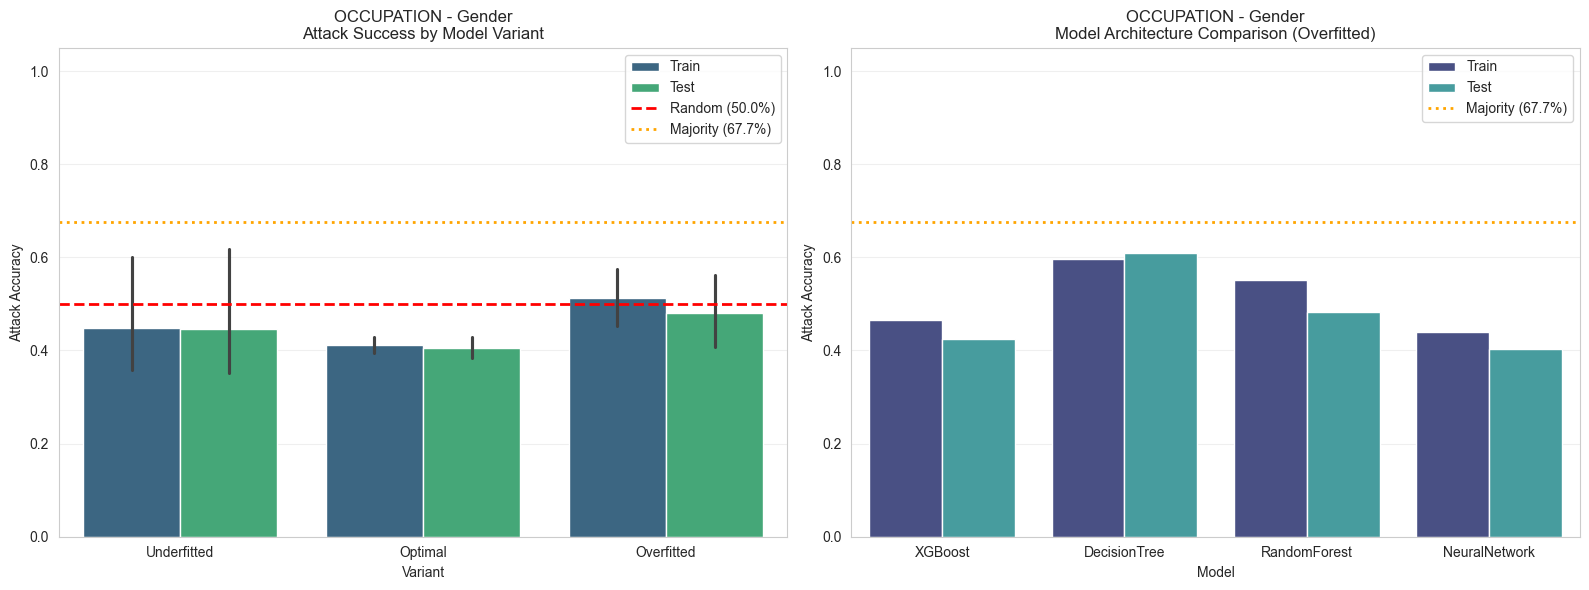

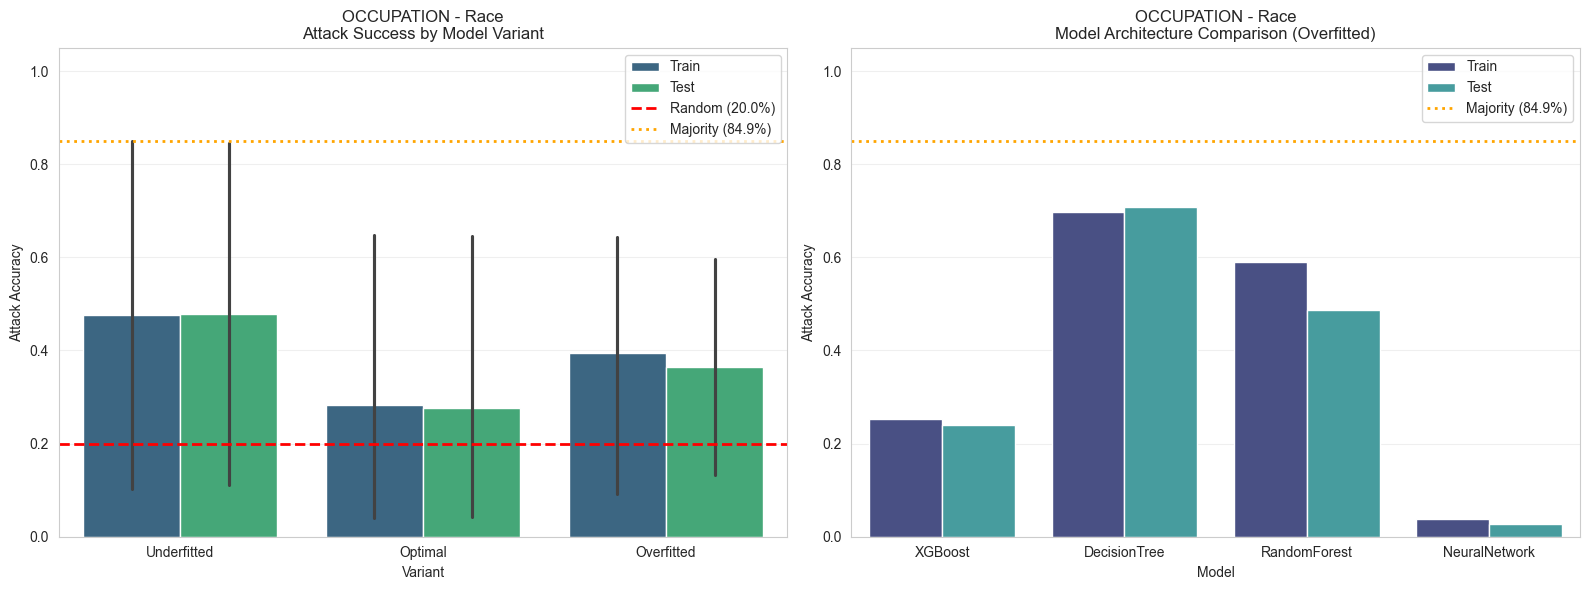

In [10]:
# Visualize results
plot_attack_comparison(occupation_results, 'occupation')

### 7.4 Experiment 4: Stack Overflow Dataset

In [11]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.utils.parallel')

In [14]:
# Run on Stack Overflow dataset
stackoverflow_results = run_comprehensive_attack_experiment(
    'stackoverflow',
    model_types=['XGBoost', 'DecisionTree', 'RandomForest', 'NeuralNetwork']
)


Loading Dataset: STACKOVERFLOW
Description: Employment Status (Developer Survey Data)
Shape: (5000, 11)
Train: 4000 samples
Test:  1000 samples
Categorical features (3): ['EdLevel', 'Age', 'MentalHealth']
Numerical features (4): ['Employment', 'YearsCode', 'YearsCodePro', 'ComputerSkills']

Training XGBoost variants...

1/3: Training UNDERFITTED XGBoost...
  ✓ Training complete

2/3: Finding OPTIMAL XGBoost via GridSearch...
  ✓ Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 50}
  ✓ Best CV score: 0.7765

3/3: Training OVERFITTED XGBoost...
  ✓ Training complete

XGBoost Performance Summary:
Variant         Train Acc    Test Acc    
----------------------------------------

Training DecisionTree variants...

1/3: Training UNDERFITTED DecisionTree...
  ✓ Training complete

2/3: Finding OPTIMAL DecisionTree via GridSearch...
  ✓ Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
  ✓ Best CV score: 

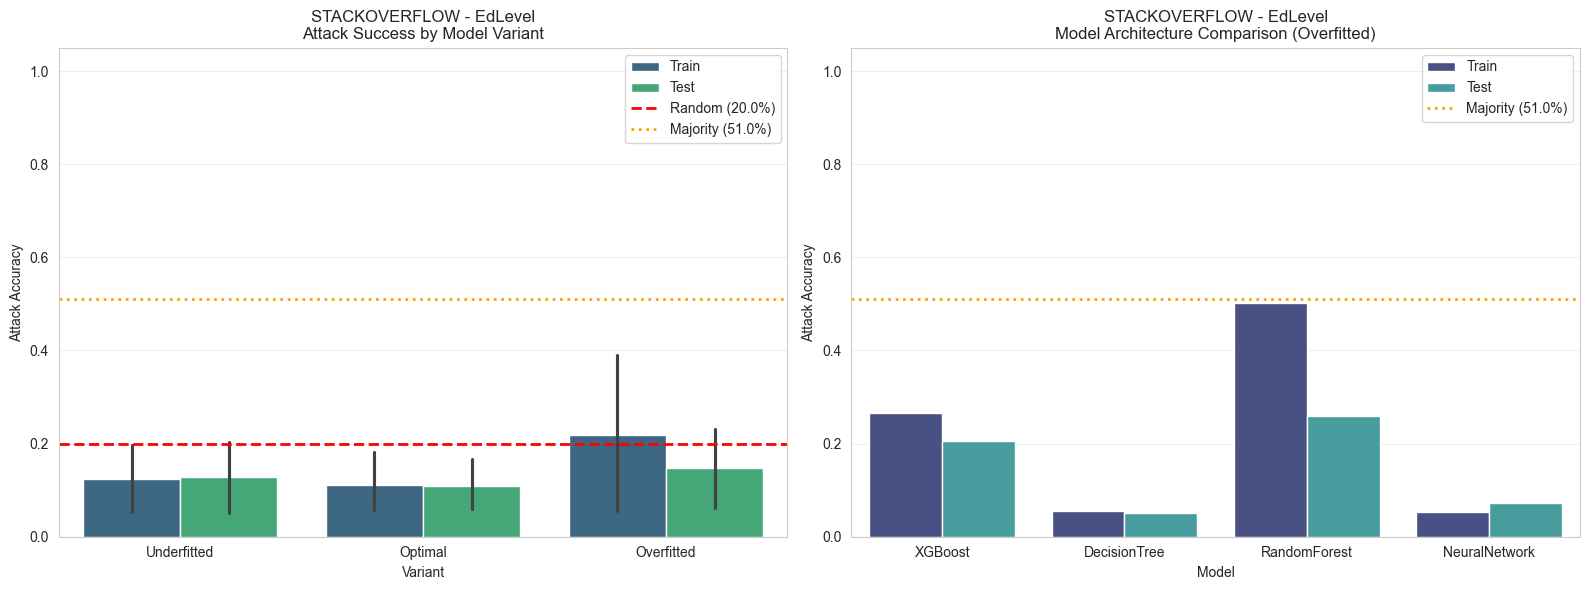

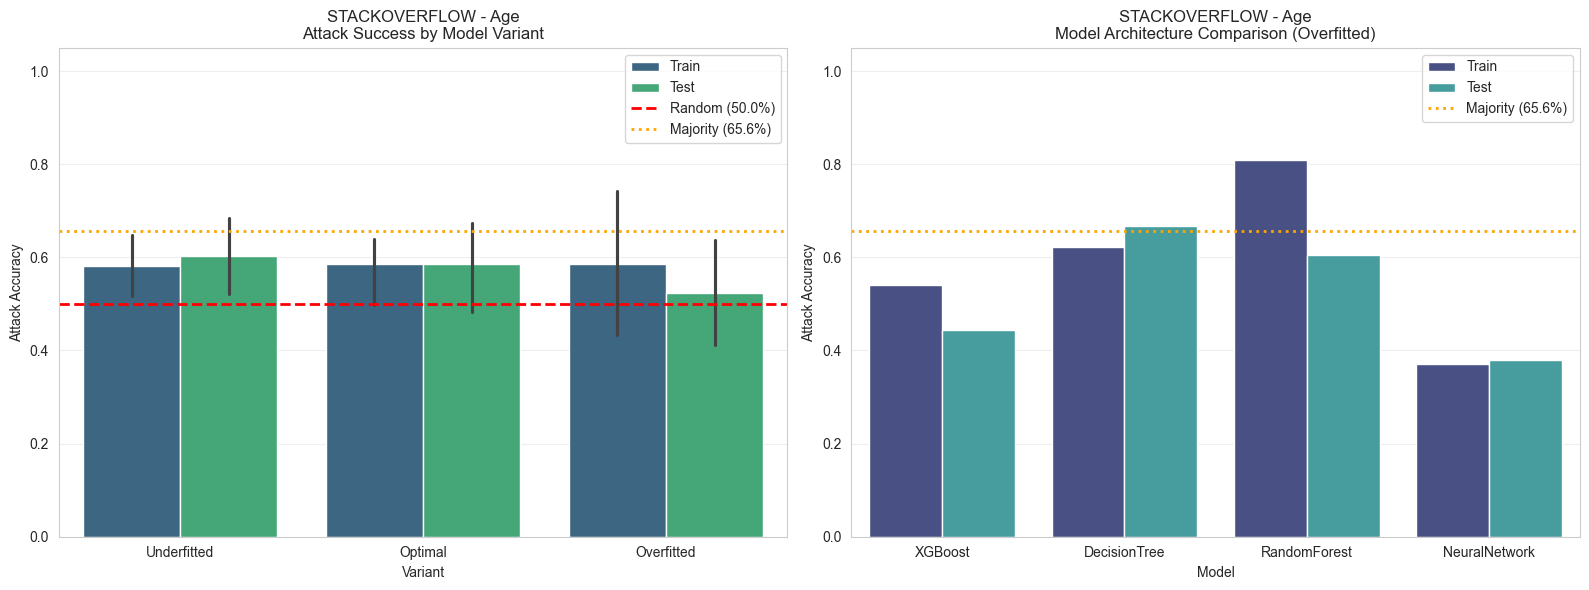

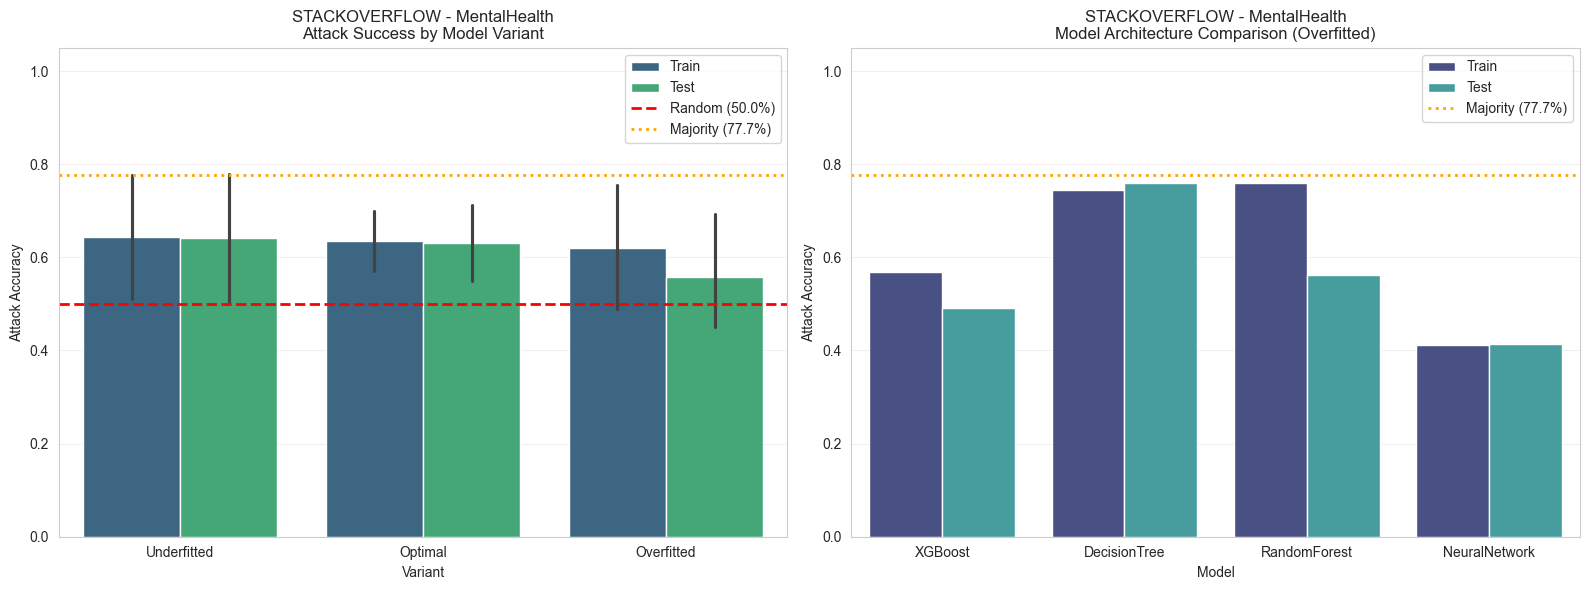

In [15]:
# Visualize results
plot_attack_comparison(stackoverflow_results, 'stackoverflow')

In [ ]:
# Save insurance results
insurance_results.to_csv('results/results_insurance.csv', index=False)
print("✓ Insurance results saved to results/results_insurance.csv")
# Save personality results
personality_results.to_csv('results/results_personality.csv', index=False)
print("✓ Personality results saved to results/results_personality.csv")
# Save occupation results
occupation_results.to_csv('results/results_occupation.csv', index=False)
print("✓ Occupation results saved to results/results_occupation.csv")
# Save stackoverflow results
stackoverflow_results.to_csv('results/results_stackoverflow.csv', index=False)
print("✓ Stack Overflow results saved to results/results_stackoverflow.csv")

✓ Stack Overflow results saved to results_stackoverflow.csv


In [ ]:
insurance_results = pd.read_csv('results/results_insurance.csv')
personality_results = pd.read_csv('results/results_personality.csv')
occupation_results = pd.read_csv('results/results_occupation.csv')
stackoverflow_results = pd.read_csv('results/results_stackoverflow.csv')

## 8. Comprehensive Analysis Across All Datasets

In [18]:
# Combine all results
all_results = pd.concat([
    insurance_results,
    personality_results,
    occupation_results,
    stackoverflow_results
], ignore_index=True)

# Create summary
summary = create_summary_table(all_results)


ATTACK SUMMARY - TOP 10 MOST SUCCESSFUL ATTACKS
      Dataset      Feature        Model     Variant  Data  Attack_Accuracy  Majority_Baseline  Successful_Attack  Improvement_Over_Baseline
   occupation         Race DecisionTree     Optimal Train          0.85025             0.8492               True                   1.001236
   occupation         Race      XGBoost Underfitted Train          0.85025             0.8492               True                   1.001236
   occupation         Race DecisionTree Underfitted Train          0.85025             0.8492               True                   1.001236
   occupation         Race      XGBoost Underfitted  Test          0.84500             0.8492              False                   0.995054
   occupation         Race DecisionTree Underfitted  Test          0.84500             0.8492              False                   0.995054
   occupation         Race DecisionTree     Optimal  Test          0.84500             0.8492              Fals

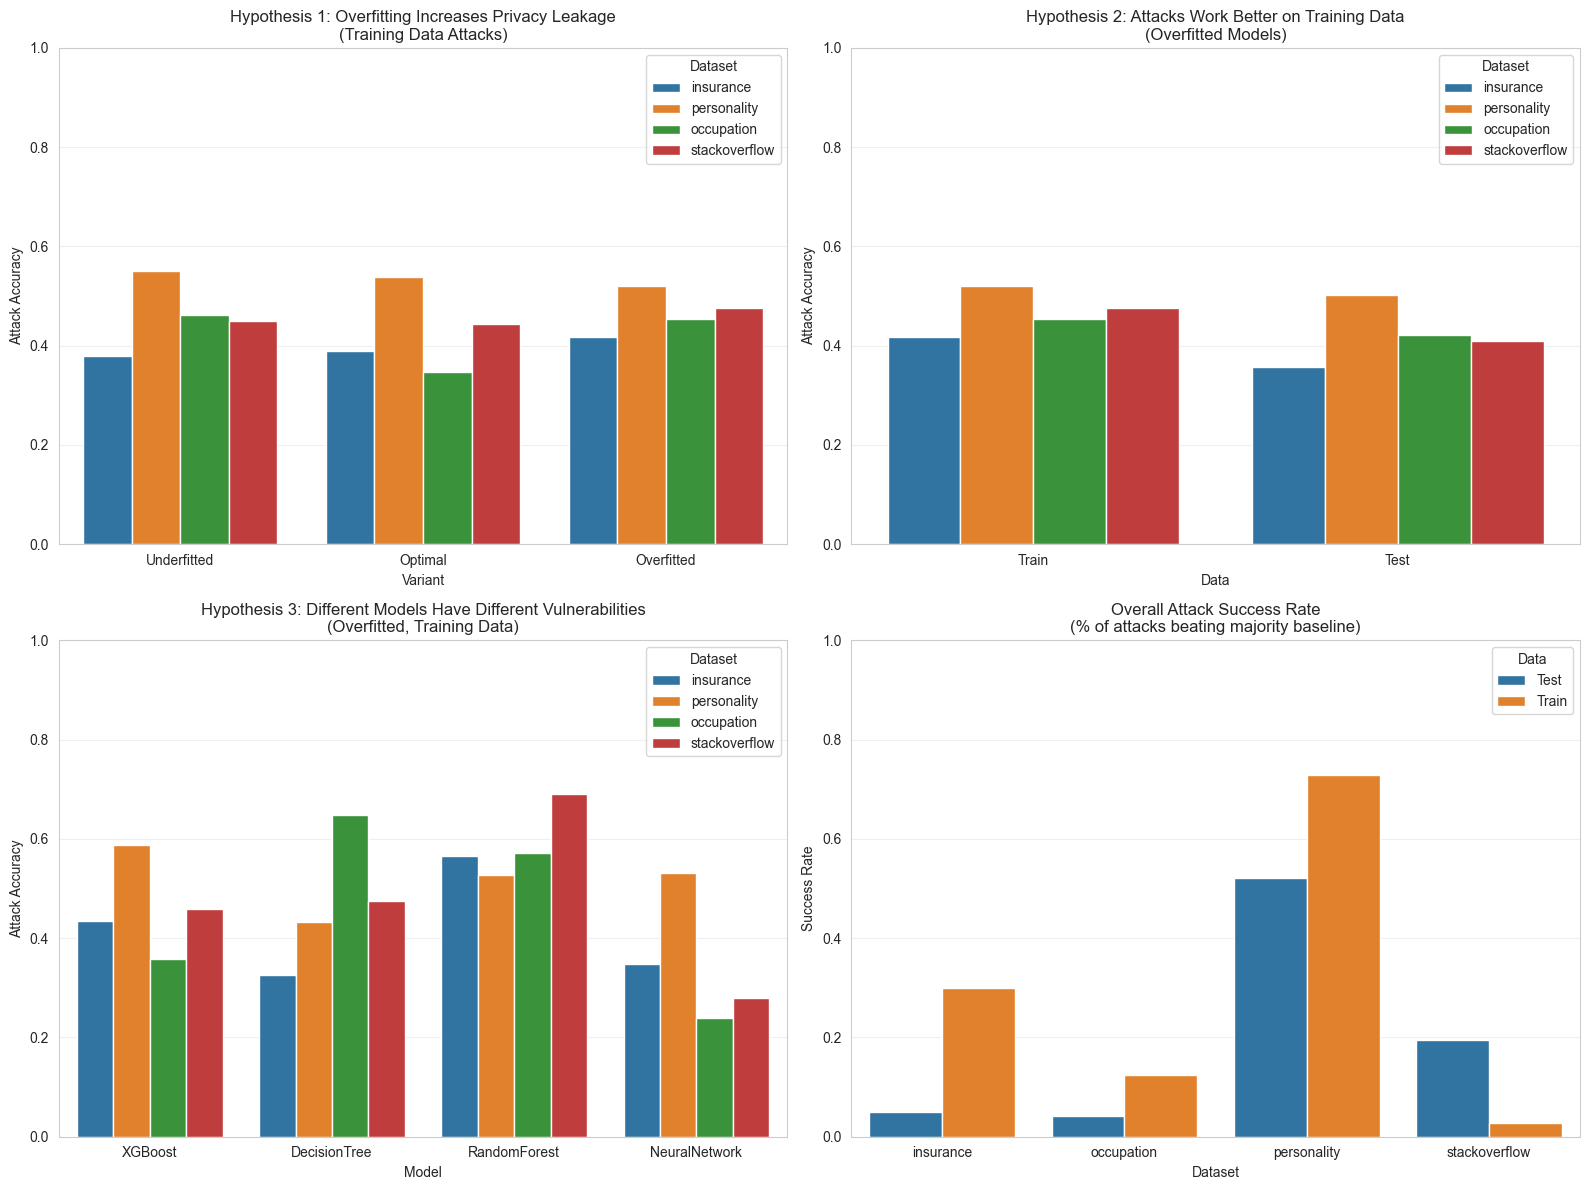

In [19]:
# Overall comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Overfitting Effect
ax1 = axes[0, 0]
overfit_data = all_results[all_results['Data'] == 'Train']
sns.barplot(
    data=overfit_data,
    x='Variant',
    y='Attack_Accuracy',
    hue='Dataset',
    ax=ax1,
    ci=None
)
ax1.set_title('Hypothesis 1: Overfitting Increases Privacy Leakage\n(Training Data Attacks)')
ax1.set_ylabel('Attack Accuracy')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Train vs Test
ax2 = axes[0, 1]
overfitted_only = all_results[all_results['Variant'] == 'Overfitted']
sns.barplot(
    data=overfitted_only,
    x='Data',
    y='Attack_Accuracy',
    hue='Dataset',
    ax=ax2,
    ci=None
)
ax2.set_title('Hypothesis 2: Attacks Work Better on Training Data\n(Overfitted Models)')
ax2.set_ylabel('Attack Accuracy')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Model Architecture Comparison
ax3 = axes[1, 0]
model_comparison = all_results[
    (all_results['Variant'] == 'Overfitted') & 
    (all_results['Data'] == 'Train')
]
sns.barplot(
    data=model_comparison,
    x='Model',
    y='Attack_Accuracy',
    hue='Dataset',
    ax=ax3,
    ci=None
)
ax3.set_title('Hypothesis 3: Different Models Have Different Vulnerabilities\n(Overfitted, Training Data)')
ax3.set_ylabel('Attack Accuracy')
ax3.set_ylim(0, 1)
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Success Rate by Dataset
ax4 = axes[1, 1]
success_by_dataset = all_results.groupby(['Dataset', 'Data']).apply(
    lambda x: (x['Attack_Accuracy'] > x['Majority_Baseline']).mean()
).reset_index(name='Success_Rate')
sns.barplot(
    data=success_by_dataset,
    x='Dataset',
    y='Success_Rate',
    hue='Data',
    ax=ax4
)
ax4.set_title('Overall Attack Success Rate\n(% of attacks beating majority baseline)')
ax4.set_ylabel('Success Rate')
ax4.set_ylim(0, 1)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Key Findings

Run this cell after experiments complete to see automated findings:

In [20]:
print("\n" + "="*100)
print("KEY FINDINGS - ATTRIBUTE INFERENCE ATTACK EVALUATION")
print("="*100)

# Finding 1: Effect of overfitting
print("\n1. EFFECT OF MODEL OVERFITTING:")
train_data = all_results[all_results['Data'] == 'Train']
overfit_effect = train_data.groupby('Variant')['Attack_Accuracy'].mean()
print(f"   Underfitted models: {overfit_effect.get('Underfitted', 0):.2%} avg attack accuracy")
print(f"   Optimal models:     {overfit_effect.get('Optimal', 0):.2%} avg attack accuracy")
print(f"   Overfitted models:  {overfit_effect.get('Overfitted', 0):.2%} avg attack accuracy")

if overfit_effect.get('Overfitted', 0) > overfit_effect.get('Optimal', 0):
    print("   ✓ CONFIRMED: Overfitted models leak more information")

# Finding 2: Train vs Test
print("\n2. TRAINING DATA vs TEST DATA:")
overfitted = all_results[all_results['Variant'] == 'Overfitted']
train_vs_test = overfitted.groupby('Data')['Attack_Accuracy'].mean()
print(f"   Train data attacks: {train_vs_test.get('Train', 0):.2%} avg accuracy")
print(f"   Test data attacks:  {train_vs_test.get('Test', 0):.2%} avg accuracy")

if train_vs_test.get('Train', 0) > train_vs_test.get('Test', 0):
    print("   ✓ CONFIRMED: Attacks more successful on training data (memorization effect)")

# Finding 3: Most vulnerable features
print("\n3. MOST VULNERABLE FEATURES:")
feature_vulnerability = all_results[
    (all_results['Variant'] == 'Overfitted') & 
    (all_results['Data'] == 'Train')
].groupby('Feature')['Attack_Accuracy'].mean().sort_values(ascending=False)
print("   Top 5 most vulnerable:")
for feat, acc in feature_vulnerability.head(5).items():
    print(f"     - {feat}: {acc:.2%}")

# Finding 4: Most vulnerable model
print("\n4. MOST VULNERABLE MODEL ARCHITECTURE:")
model_vulnerability = all_results[
    (all_results['Variant'] == 'Overfitted') & 
    (all_results['Data'] == 'Train')
].groupby('Model')['Attack_Accuracy'].mean().sort_values(ascending=False)
for model, acc in model_vulnerability.items():
    print(f"   - {model}: {acc:.2%}")

# Finding 5: Dataset comparison
print("\n5. DATASET VULNERABILITY COMPARISON:")
dataset_vuln = all_results[
    (all_results['Variant'] == 'Overfitted') & 
    (all_results['Data'] == 'Train')
].groupby('Dataset')['Attack_Accuracy'].mean().sort_values(ascending=False)
for dataset, acc in dataset_vuln.items():
    print(f"   - {dataset}: {acc:.2%}")

print("\n" + "="*100)


KEY FINDINGS - ATTRIBUTE INFERENCE ATTACK EVALUATION

1. EFFECT OF MODEL OVERFITTING:
   Underfitted models: 45.57% avg attack accuracy
   Optimal models:     43.80% avg attack accuracy
   Overfitted models:  46.45% avg attack accuracy
   ✓ CONFIRMED: Overfitted models leak more information

2. TRAINING DATA vs TEST DATA:
   Train data attacks: 46.45% avg accuracy
   Test data attacks:  41.88% avg accuracy
   ✓ CONFIRMED: Attacks more successful on training data (memorization effect)

3. MOST VULNERABLE FEATURES:
   Top 5 most vulnerable:
     - MentalHealth: 62.11%
     - Age: 58.54%
     - Stage_fear: 58.02%
     - Drained_after_socializing: 57.06%
     - HAS_CHILDREN: 55.61%

4. MOST VULNERABLE MODEL ARCHITECTURE:
   - RandomForest: 58.23%
   - XGBoost: 47.23%
   - DecisionTree: 43.37%
   - NeuralNetwork: 36.97%

5. DATASET VULNERABILITY COMPARISON:
   - personality: 51.97%
   - stackoverflow: 47.53%
   - occupation: 45.40%
   - insurance: 41.80%



## 10. Save Results for Report

In [ ]:
# Save complete results
all_results.to_csv('results/rattack_results_comprehensive.csv', index=False)
summary.to_csv('results/attack_results_summary.csv', index=False)

print("Results saved:")
print("   - rattack_results_comprehensive.csv")
print("   - attack_results_summary.csv")

Results saved:
   - attack_results_comprehensive.csv
   - attack_results_summary.csv


---

## Summary of Datasets

This notebook integrates both the **original POC work** and **new datasets**:

### 1. Insurance Dataset (Original POC)
- **Source**: Original proof-of-concept notebook
- **Rows**: ~1,300
- **Target**: Insurance charges (converted to quartiles Q1-Q4)
- **Categorical Features**: SEX, SMOKER, REGION, BMI_CATEGORY, HAS_CHILDREN
- **Key Feature**: SMOKER (highly predictive of charges)
- **Note**: This dataset validates the original attack methodology

### 2. Personality Dataset
- **Rows**: 5,000
- **Target**: Personality (Introvert/Extrovert)
- **Categorical Features**: Stage_fear, Drained_after_socializing, Time_Alone_Category, Social_Events_Category
- **Balance**: Excellent (50/50 target split)
- **Privacy Concern**: Psychological profiling

### 3. Occupation Dataset (Adult Income)
- **Rows**: 15,087
- **Target**: Income (<=50K / >50K)
- **Categorical Features**: Gender, Race, MaritalStatus, Education, Occupation
- **Balance**: Imbalanced (75/25)
- **Privacy Concern**: Inferring race or gender from employment data

### 4. Stack Overflow Dataset
- **Rows**: 73,462 (largest dataset)
- **Target**: Employed (0/1)
- **Categorical Features**: EdLevel, Age, MentalHealth (selected for balance)
- **Privacy Concern**: Mental health disclosure, age discrimination

---